In [22]:
import pandas as pd 
df= pd. read_csv("../data/processed/cleaned_data.csv")

In [23]:
df.head(10)

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
5,2,115.0,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,15250.0
6,1,158.0,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,17710.0
7,1,115.0,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,18920.0
8,1,158.0,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140.0,5500.0,17,20,23875.0
9,0,115.0,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160.0,5500.0,16,22,10295.0


In [3]:
df.shape

(205, 26)

Detect and handle outliers in numerical features


In [ ]:
#Identify outliers using IQR methods 

# select the datatype   
for col in df.select_dtypes(include='number').columns:
   Q1 = df[col].quantile(0.25)
   Q3 = df[col].quantile(0.75)

   # difference between Q3 & Q1
   # It represent the range where the central 50% of the data lies
   IQR = Q3 -Q1

   lower = Q1 -1.5 * IQR
   upper = Q3 + 1.5 * IQR

outliers = df [(df[col] < lower ) | (df [col] > upper)]

#print the columns name followed by outliers  values
print(f"{col} outliers")
print(outliers[col])

price outliers
15     30760.0
16     41315.0
17     36880.0
47     32250.0
48     35550.0
49     36000.0
70     31600.0
71     34184.0
72     35056.0
73     40960.0
74     45400.0
126    32528.0
127    34028.0
128    37028.0
Name: price, dtype: float64


 visualize using boxplot


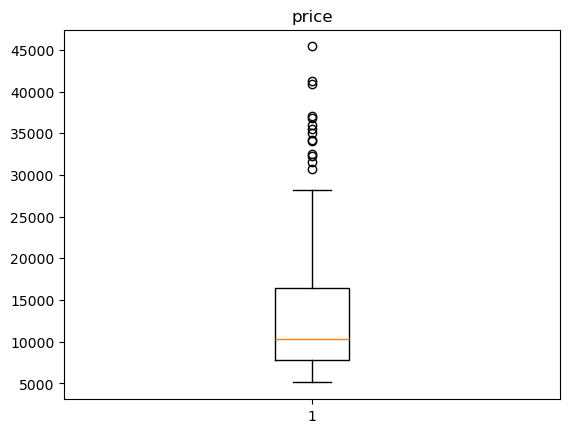

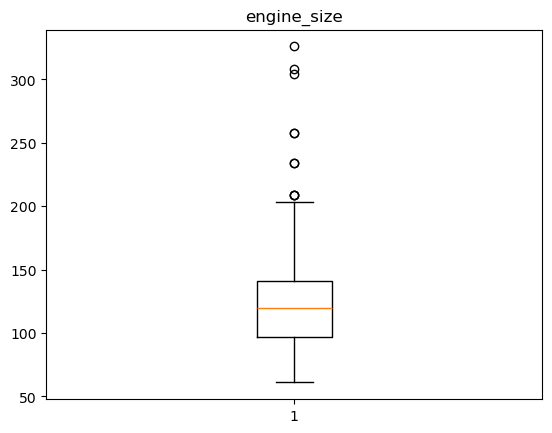

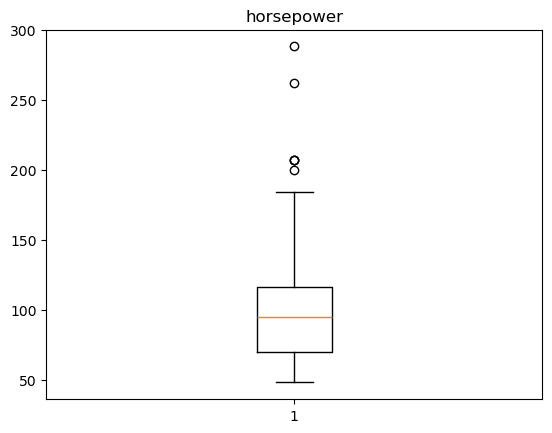

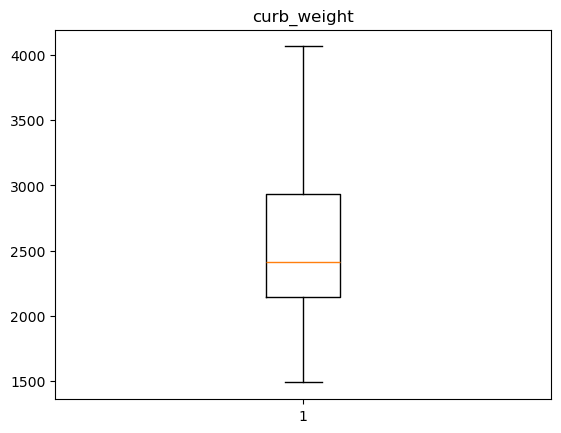

In [22]:
#  import matplotlib 
import matplotlib.pyplot as plt

# select the specific cols 
cols =['price','engine_size','horsepower', 'curb_weight'] 
# for col in df.select_dtypes(include='number').columns:

for col in cols:
    # boxplot for the selected cols
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

outliers cap

In [ ]:
# required columns
cols = ['price', 'engine_size', 'horsepower', 'curb_weight']  

# loop in every column
for col in cols:   
    Q1 = df[col].quantile(0.25)   # 25% value
    Q3 = df[col].quantile(0.75)   # 75% value
    IQR = Q3 - Q1                
    low = Q1 - 1.5 * IQR          # lower limit
    high = Q3 + 1.5 * IQR         # upper limit

    df[col] = df[col].clip(low, high)  
    # less than low value = low 
    # more than high value = high 

# Saving cleaned dataset to processed folder
df.to_csv("../data/processed/cleaned_no_outlier.csv", index=False)  


In [ ]:
# Outliers detections
# Detect and handle outliers in numerical features

# Identify outliers using IQR methods 
# -- the price columns have the more outliers

#visualizing  outliers using boxplot
#-- In the price,engine_size, & horsepower have more outliers
#-- The curb_weight have less outliers

#Outliers Cap (Limits values)
#--It calculate the lower and upper limits 
#-- Values below/ above limits are capped 
#-- Outliers are not removed, it just adjusted

#The cleaned (no outliers) data is saved to csv files
